In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, f1_score, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

In [6]:
df=pd.read_csv('./Iris.csv')
df.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [7]:
print(df.groupby('Species').size())
print(df.isnull().sum())
print('Размер датасета :',df.shape)

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Размер датасета : (150, 6)


In [8]:
print(df.dtypes)

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object


In [9]:
Y = df['Species']
X = df.drop('Species', axis=1)
X = X.set_index('Id')

In [10]:
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Id,,,,
1,5.1,3.5,1.4,0.2
2,4.9,3.0,1.4,0.2
3,4.7,3.2,1.3,0.2
4,4.6,3.1,1.5,0.2
5,5.0,3.6,1.4,0.2


In [11]:
Y=Y.map({'Iris-setosa': 1, 'Iris-versicolor': 2, 'Iris-virginica': 3 })
Y.head()

0    1
1    1
2    1
3    1
4    1
Name: Species, dtype: int64

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

Decision Tree Model

In [13]:
decision_tree_model = DecisionTreeClassifier(random_state=42, max_depth=8)
decision_tree_model.fit(X_train, Y_train)

train_predictions_decision_tree = decision_tree_model.predict(X_train)
test_predictions_decision_tree = decision_tree_model.predict(X_test)

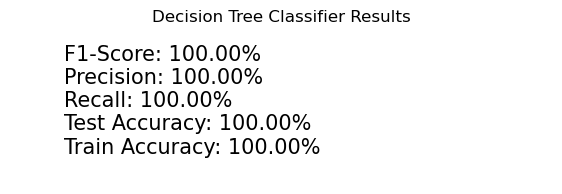

<Figure size 1000x1000 with 0 Axes>

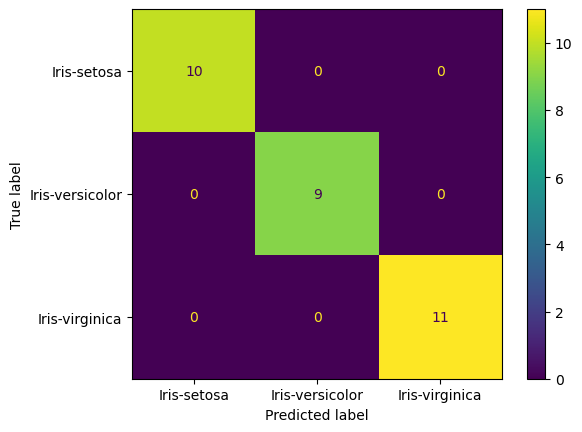

In [14]:
train_accuracy_decision_tree = accuracy_score(Y_train,train_predictions_decision_tree)
test_accuracy_decision_tree = accuracy_score(Y_test,test_predictions_decision_tree)
recall_decision_tree = recall_score(Y_test, test_predictions_decision_tree, average='macro')
precision_decision_tree = precision_score(Y_test, test_predictions_decision_tree, average='macro')
f1_decision_tree = f1_score(Y_test, test_predictions_decision_tree, average='macro')
cm_decision_tree = confusion_matrix(Y_test, test_predictions_decision_tree)
plt.figure(figsize=(7,2))
plt.title('Decision Tree Classifier Results')
plt.axis('off')
plt.text(0.1, 0.8, f"F1-Score: {f1_decision_tree * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.1, 0.65, f"Precision: {precision_decision_tree * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.1, 0.5, f"Recall: {recall_decision_tree * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.1, 0.35, f"Test Accuracy: {test_accuracy_decision_tree * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.1, 0.2, f"Train Accuracy: {train_accuracy_decision_tree * 100:.2f}%", fontsize=15, ha='left')
plt.figure(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions( Y_test, test_predictions_decision_tree, display_labels=['Iris-setosa','Iris-versicolor', 'Iris-virginica'])

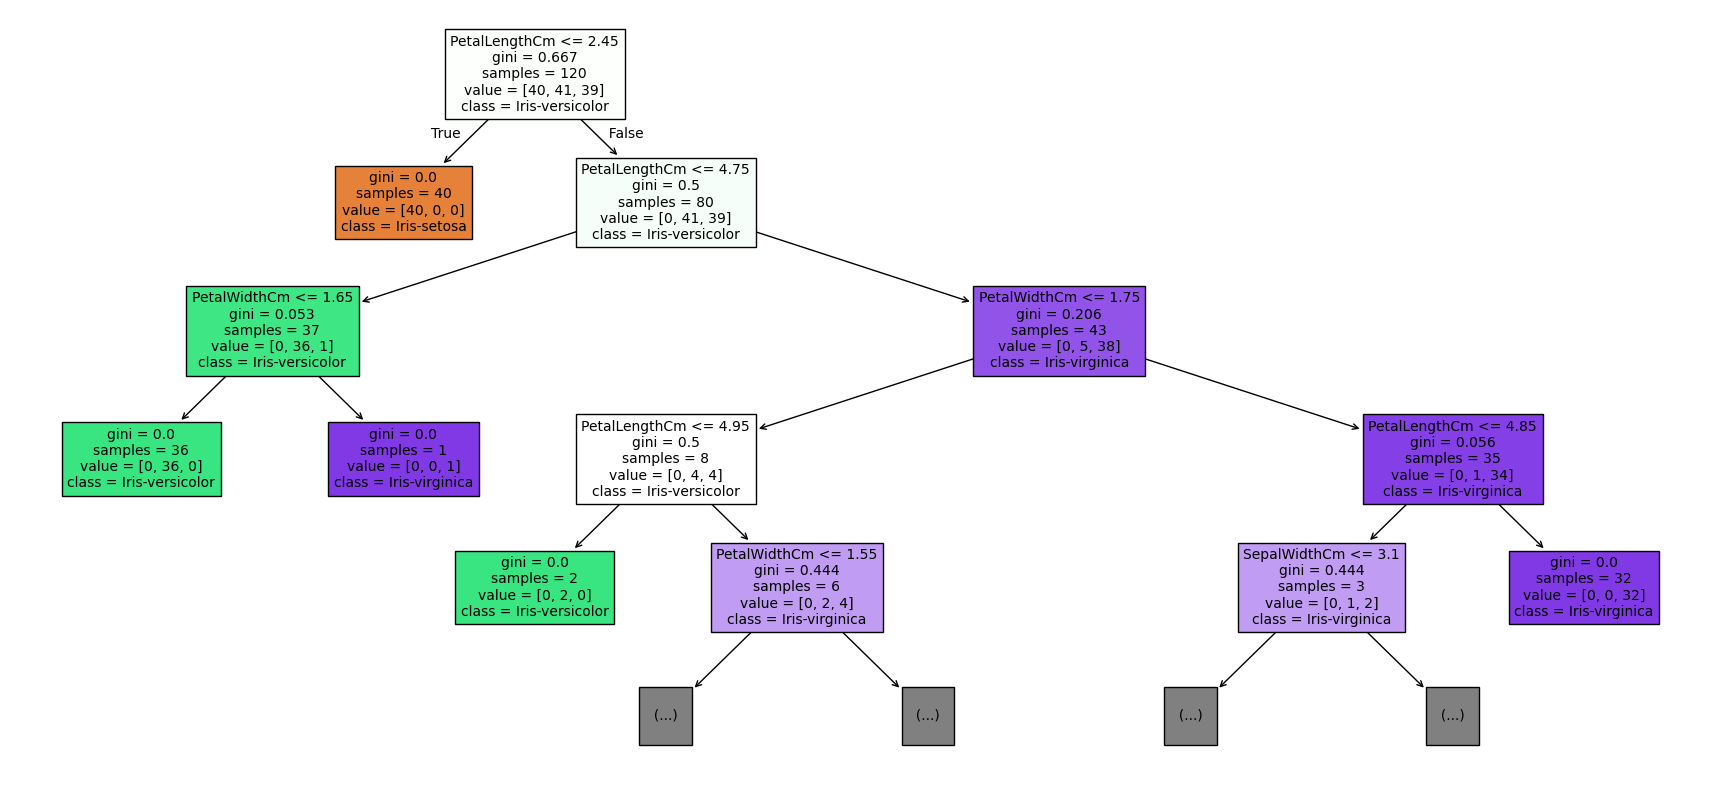

In [15]:
plt.figure(figsize=(22, 10))
plot_tree(decision_tree_model, max_depth=4, feature_names=X_train.columns, 
          class_names=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], 
          filled=True, rounded=False, fontsize=10
)  
plt.show()

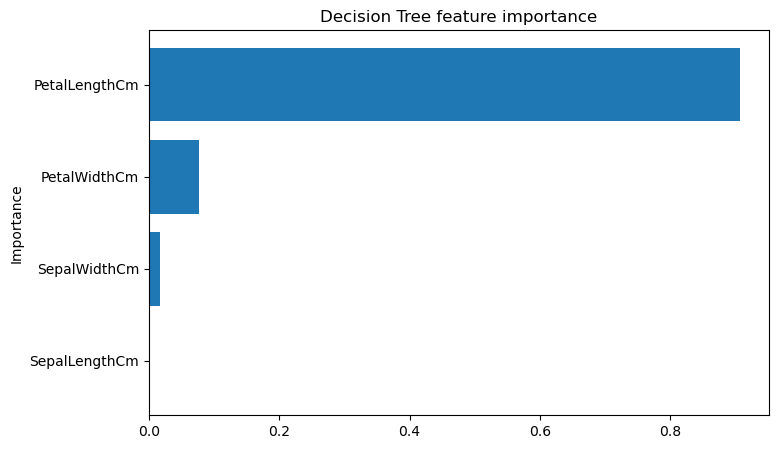

In [16]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': decision_tree_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.ylabel('Importance')
plt.title('Decision Tree feature importance')
plt.show()

Random Forest

In [17]:
random_forest_model = RandomForestClassifier(random_state=42, max_depth=8)
random_forest_model.fit(X_train, Y_train)
train_predictions_random_forest = random_forest_model.predict(X_train)
test_predictions_random_forest = random_forest_model.predict(X_test)

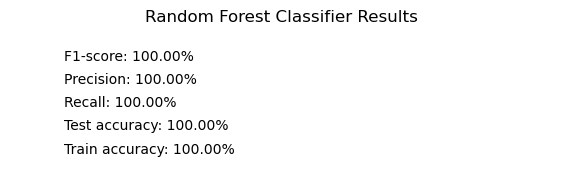

<Figure size 1000x1000 with 0 Axes>

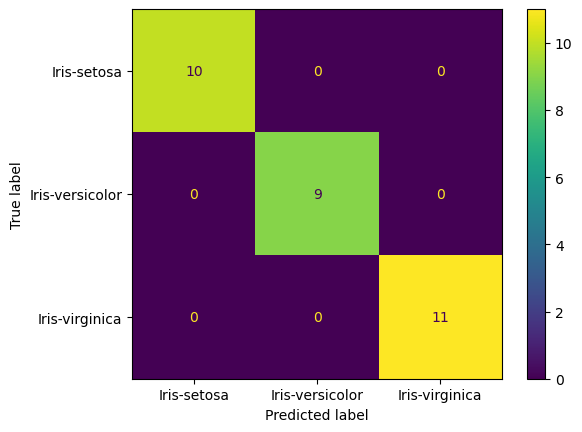

In [18]:
train_accuracy_random_forest = accuracy_score(Y_train, train_predictions_random_forest)
test_accuracy_random_forest= accuracy_score(Y_test, test_predictions_random_forest)
precision_random_forest = precision_score(Y_test, test_predictions_random_forest, average='macro')
recall_random_forest = recall_score(Y_test, test_predictions_random_forest, average='macro')
f1_random_forest = f1_score(Y_test, test_predictions_random_forest, average='macro')
cm_random_forest = confusion_matrix(Y_test, test_predictions_random_forest)

plt.figure(figsize=(7,2))
plt.title('Random Forest Classifier Results')
plt.axis('off')
plt.text(0.1, 0.8, f"F1-score: {f1_random_forest * 100:.2f}%", fontsize=10, ha='left')
plt.text(0.1, 0.65, f"Precision: {precision_random_forest * 100 :.2f}%", fontsize = 10, ha='left')
plt.text(0.1, 0.5, f"Recall: {recall_random_forest * 100 :.2f}%", fontsize = 10, ha='left')
plt.text(0.1, 0.35, f"Test accuracy: {test_accuracy_random_forest * 100 :.2f}%", fontsize = 10, ha='left')
plt.text(0.1, 0.2, f"Train accuracy: {train_accuracy_random_forest * 100 :.2f}%", fontsize = 10, ha='left')
plt.figure(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(Y_test, test_predictions_random_forest, display_labels=['Iris-setosa','Iris-versicolor', 'Iris-virginica'])

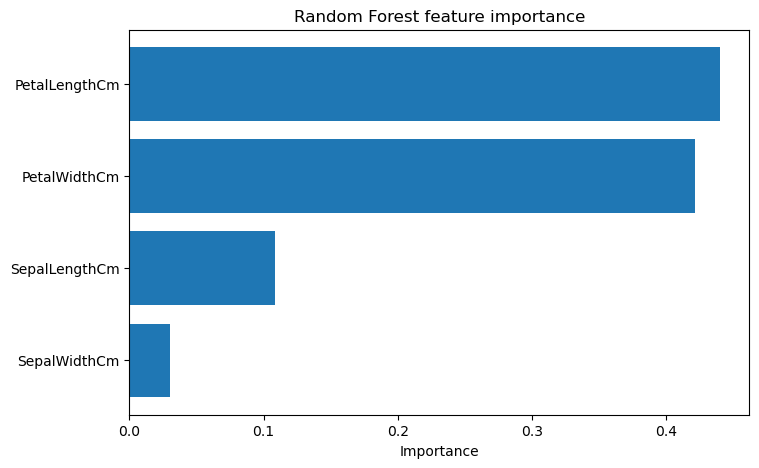

In [19]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': random_forest_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Random Forest feature importance')
plt.show()

Gradient Boosting

In [29]:
catboost_model = CatBoostClassifier(random_state=42, max_depth=4,verbose=False)
catboost_model.fit(X_train, Y_train)
train_predictions_catboost = catboost_model.predict(X_train)
test_predictions_catboost = catboost_model.predict(X_test)

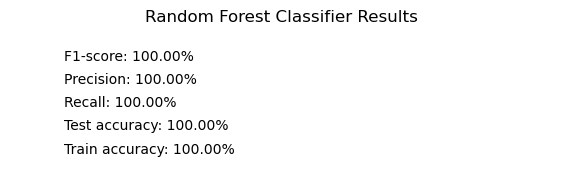

<Figure size 1000x1000 with 0 Axes>

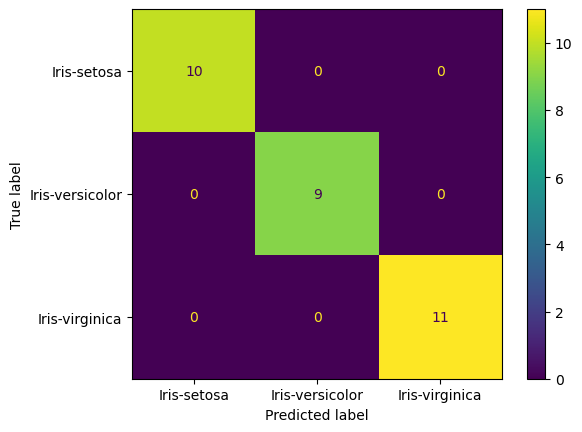

In [22]:
train_accuracy_catboost = accuracy_score(Y_train, train_predictions_catboost)
test_accuracy_catboost= accuracy_score(Y_test, test_predictions_catboost)
precision_catboost = precision_score(Y_test, test_predictions_catboost, average='macro')
recall_catboost = recall_score(Y_test, test_predictions_catboost, average='macro')
f1_catboost = f1_score(Y_test, test_predictions_catboost, average='macro')
cm_catboost = confusion_matrix(Y_test, test_predictions_catboost)

plt.figure(figsize=(7,2))
plt.title('Random Forest Classifier Results')
plt.axis('off')
plt.text(0.1, 0.8, f"F1-score: {f1_catboost * 100:.2f}%", fontsize=10, ha='left')
plt.text(0.1, 0.65, f"Precision: {precision_catboost * 100 :.2f}%", fontsize = 10, ha='left')
plt.text(0.1, 0.5, f"Recall: {recall_catboost * 100 :.2f}%", fontsize = 10, ha='left')
plt.text(0.1, 0.35, f"Test accuracy: {test_accuracy_catboost * 100 :.2f}%", fontsize = 10, ha='left')
plt.text(0.1, 0.2, f"Train accuracy: {train_accuracy_catboost * 100 :.2f}%", fontsize = 10, ha='left')
plt.figure(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(Y_test, test_predictions_catboost, display_labels=['Iris-setosa','Iris-versicolor', 'Iris-virginica'])

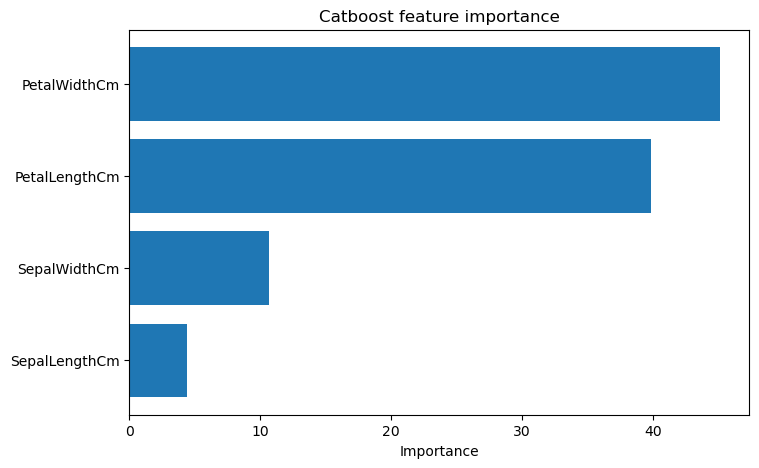

In [23]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': catboost_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Catboost feature importance')
plt.show()

In [25]:
xgboost_model = XGBClassifier(random_state=42, max_depth=4)
Y_train = Y_train.map({
    1: 0,
    2: 1,
    3: 2
})
xgboost_model.fit(X_train, Y_train)
train_predictions_xgboost = xgboost_model.predict(X_train)
test_predictions_xgboost = xgboost_model.predict(X_test)

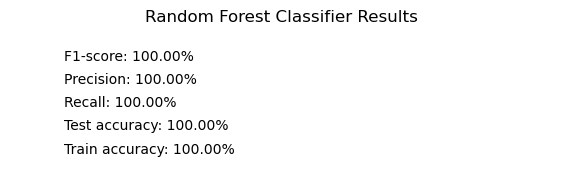

<Figure size 1000x1000 with 0 Axes>

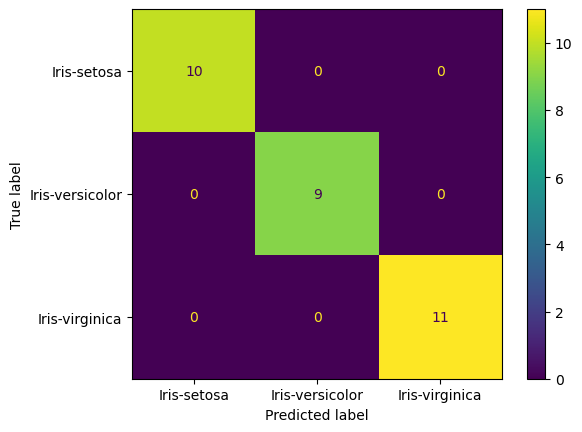

In [27]:
Y_test = Y_test.map({
    1: 0,
    2: 1,
    3: 2
})
train_accuracy_xgboost = accuracy_score(Y_train, train_predictions_xgboost)
test_accuracy_xgboost= accuracy_score(Y_test, test_predictions_xgboost)
precision_xgboost = precision_score(Y_test, test_predictions_xgboost, average='macro')
recall_xgboost = recall_score(Y_test, test_predictions_xgboost, average='macro')
f1_xgboost = f1_score(Y_test, test_predictions_xgboost, average='macro')
cm_xgboost = confusion_matrix(Y_test, test_predictions_xgboost)

plt.figure(figsize=(7,2))
plt.title('Random Forest Classifier Results')
plt.axis('off')
plt.text(0.1, 0.8, f"F1-score: {f1_xgboost * 100:.2f}%", fontsize=10, ha='left')
plt.text(0.1, 0.65, f"Precision: {precision_xgboost * 100 :.2f}%", fontsize = 10, ha='left')
plt.text(0.1, 0.5, f"Recall: {recall_xgboost * 100 :.2f}%", fontsize = 10, ha='left')
plt.text(0.1, 0.35, f"Test accuracy: {test_accuracy_xgboost * 100 :.2f}%", fontsize = 10, ha='left')
plt.text(0.1, 0.2, f"Train accuracy: {train_accuracy_xgboost * 100 :.2f}%", fontsize = 10, ha='left')
plt.figure(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(Y_test, test_predictions_xgboost, display_labels=['Iris-setosa','Iris-versicolor', 'Iris-virginica'])

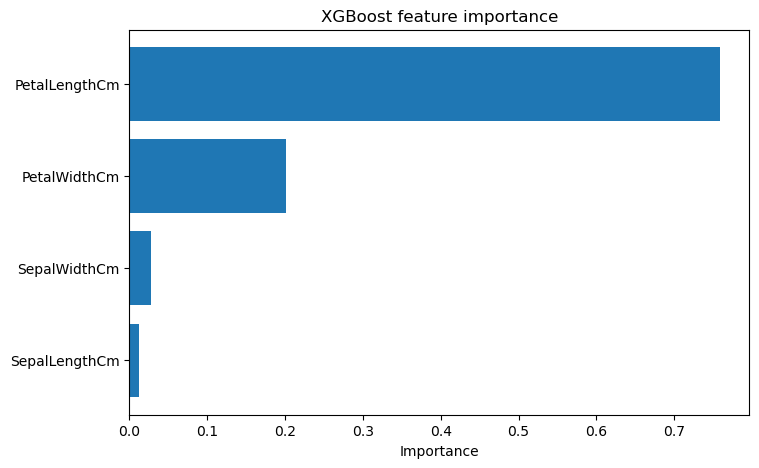

In [28]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgboost_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('XGBoost feature importance')
plt.show()